In [1]:
using Revise
using PrecisionCarriers
using Random
using Pkg
Pkg.develop(url="/home/antonr/repos/QEDbase.jl")
Pkg.develop(url="/home/antonr/repos/QEDcore.jl")
Pkg.develop(url="/home/antonr/repos/QEDprocesses.jl")
Pkg.develop(url="/home/antonr/repos/QEDFeynmanDiagrams.jl")
using QEDbase, QEDcore, QEDprocesses, QEDFeynmanDiagrams

   Resolving package versions...
    Updating `~/repos/PrecisionCarriers.jl/Project.toml`
  [10e22c08] + QEDbase v0.4.0 `~/repos/QEDbase.jl`
    Updating `~/repos/PrecisionCarriers.jl/Manifest.toml`
  [7d9f7c33] + Accessors v0.1.42
  [dce04be8] + ArgCheck v2.5.0
  [49dc2e85] + Calculus v0.5.2
  [38540f10] + CommonSolve v0.2.4
  [a33af91c] + CompositionsBase v0.1.2
  [187b0558] + ConstructionBase v1.6.0
  [ffbed154] + DocStringExtensions v0.9.5
  [3587e190] + InverseFunctions v0.1.17
  [1914dd2f] + MacroTools v0.5.16
  [eff96d63] + Measurements v2.14.0
  [5ad8b20f] + PhysicalConstants v0.2.4
⌅ [aea7be01] + PrecompileTools v1.2.1
  [21216c6a] + Preferences v1.4.3
  [10e22c08] + QEDbase v0.4.0 `~/repos/QEDbase.jl`
  [f2b01f46] + Roots v2.2.8
  [699a6c99] + SimpleTraits v0.9.4
  [90137ffa] + StaticArrays v1.9.13
  [1e83bf80] + StaticArraysCore v1.4.3
  [1986cc42] + Unitful v1.23.1
  [2f01184e] + SparseArrays v1.11.0
  [bea87d4a] + SuiteSparse_jll v7.7.0+0
        Info Packages marked with 

In [14]:
RNG = MersenneTwister(0)

FLOAT_T = PrecisionCarrier{Float64}

PROC = Compton()
MODEL = PerturbativeQED()
PSL = ComptonSphericalLayout(ComptonRestSystem(Energy(2)))

OMEGA = 1.0e3

N_PHIS = 10
N_COS = 2000

PHIS_LIMS = (0.0, 2*pi)
PHIS = (PHIS_LIMS[2] - PHIS_LIMS[1]) .* [(0.0:1.0/N_PHIS:1.0)..., ] .+ PHIS_LIMS[1]

COS_THETAS_LIMS = (0.999, 1.0)
COS_THETAS = (COS_THETAS_LIMS[2] - COS_THETAS_LIMS[1]) .* [(0.0:1.0/N_COS:1.0)..., ] .+ COS_THETAS_LIMS[1]

2001-element Vector{Float64}:
 0.999
 0.9990005
 0.999001
 0.9990015
 0.999002
 0.9990025
 0.999003
 0.9990035
 0.999004
 0.9990045
 ⋮
 0.999996
 0.9999965
 0.999997
 0.9999975
 0.999998
 0.9999985
 0.999999
 0.9999995
 1.0

In [ ]:
@bench_epsilons unsafe_differential_cross_section(PhaseSpacePoint(PROC, MODEL, PSL, (omega,), (cth, phi))) ranges = begin
    omega = (1.0, 1000.0)
    phi = (0.0, 3.0)
    cth = (0.999, 1.0)
end

In [18]:
coords = [Iterators.product(COS_THETAS, PHIS)..., ]
coords = [Iterators.zip(getindex.(coords, 1), getindex.(coords, 2))...,]
moms = (QEDbase._build_momenta.(PROC, MODEL, PSL, Ref((precify(FLOAT_T, OMEGA), )), precify(FLOAT_T, coords)))
moms = reshape(moms, (length(COS_THETAS), length(PHIS)))

max_eps = 0
for single_moms in moms
    for in_out_moms in single_moms
        for mom in in_out_moms
            epsilons = maximum(PrecisionCarriers._no_epsilons.(mom))
            if epsilons > max_eps
                println("new max epsilons $epsilons from $mom")
                max_eps = epsilons
            end
        end
    end
end
println("Maximum epsilon observed: $max_eps")

out_matrix = fill(zero(FLOAT_T), (length(COS_THETAS), length(PHIS)))

new max epsilons 1 from PrecisionCarrier{Float64}[501.0000000000002 <ε=0>, -22.35508890610816 <ε=1>, 0.0 <ε=0>, 500.5000000000002 <ε=0>]
new max epsilons 2 from PrecisionCarrier{Float64}[116.43564794341398 <ε=0>, 11.560940399355687 <ε=0>, -8.399514863867191 <ε=2>, 115.5510835913574 <ε=0>]
Maximum epsilon observed: 2


2001×11 Matrix{PrecisionCarrier{Float64}}:
 0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>  …  0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>
 0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>     0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>
 0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>     0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>
 0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>     0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>
 0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>     0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>
 0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>  …  0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>
 0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>     0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>
 0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>     0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>
 0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>     0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>
 0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>     0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>
 ⋮                                ⋱                        ⋮
 0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>     0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>
 0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>     0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>
 0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>     0.0 <ε=0>  0.0 <ε=0>  0.0 <ε=0>

In [19]:
adapted_moms = moms

2001×11 Matrix{Tuple{Tuple{SFourMomentum{PrecisionCarrier{Float64}}, SFourMomentum{PrecisionCarrier{Float64}}}, Tuple{SFourMomentum{PrecisionCarrier{Float64}}, SFourMomentum{PrecisionCarrier{Float64}}}}}:
 (([1.0 <ε=0>, 0.0 <ε=0>, 0.0 <ε=0>, 0.0 <ε=0>], [1000.0 <ε=0>, 0.0 <ε=0>, 0.0 <ε=0>, 1000.0 <ε=0>]), ([501.0000000000002 <ε=0>, -22.35508890610816 <ε=1>, 0.0 <ε=0>, 500.5000000000002 <ε=0>], [499.9999999999998 <ε=0>, 22.35508890610816 <ε=1>, 0.0 <ε=0>, 499.4999999999998 <ε=0>]))        …  (([1.0 <ε=0>, 0.0 <ε=0>, 0.0 <ε=0>, 0.0 <ε=0>], [1000.0 <ε=0>, 0.0 <ε=0>, 0.0 <ε=0>, 1000.0 <ε=0>]), ([501.0000000000002 <ε=0>, -22.35508890610816 <ε=1>, 5.475417614703973e-15 <ε=1>, 500.5000000000002 <ε=0>], [499.9999999999998 <ε=0>, 22.35508890610816 <ε=1>, -5.475417614703973e-15 <ε=1>, 499.4999999999998 <ε=0>]))
 (([1.0 <ε=0>, 0.0 <ε=0>, 0.0 <ε=0>, 0.0 <ε=0>], [1000.0 <ε=0>, 0.0 <ε=0>, 0.0 <ε=0>, 1000.0 <ε=0>]), ([500.8749687421961 <ε=0>, -22.355091002945933 <ε=0>, 0.0 <ε=0>, 500.37484371093825 <

In [28]:
using ProgressMeter
using Base.Threads

out_matrix = unsafe_differential_cross_section.(
        PhaseSpacePoint.(
            PROC,
            MODEL,
            PSL,
            Ref((precify(FLOAT_T, OMEGA), )),
            precify(FLOAT_T, coords)
        )
    )

out_matrix = reshape(out_matrix, (length(COS_THETAS), length(PHIS)))

2001×11 Matrix{PrecisionCarrier{Float64}}:
 1.6627742082712644e-5 <ε=93>   …  1.6627742082712644e-5 <ε=93>
 1.6633568527967696e-5 <ε=3>       1.6633568527967696e-5 <ε=3>
 1.66393991395244e-5 <ε=114>       1.66393991395244e-5 <ε=114>
 1.6645233921758595e-5 <ε=103>     1.6645233921758595e-5 <ε=103>
 1.66510728790571e-5 <ε=64>        1.66510728790571e-5 <ε=64>
 1.665691601581464e-5 <ε=109>   …  1.665691601581464e-5 <ε=109>
 1.6662763336423385e-5 <ε=137>     1.6662763336423385e-5 <ε=137>
 1.666861484529245e-5 <ε=2>        1.666861484529245e-5 <ε=2>
 1.667447054682579e-5 <ε=279>      1.667447054682579e-5 <ε=279>
 1.6680330445444482e-5 <ε=162>     1.6680330445444482e-5 <ε=162>
 ⋮                              ⋱  ⋮
 5.282809574082581e-5 <ε=47>       5.282809574082581e-5 <ε=47>
 5.2880680543086737e-5 <ε=275>     5.2880680543086737e-5 <ε=275>
 5.293335706561616e-5 <ε=271>      5.293335706561616e-5 <ε=271>
 5.298612552406691e-5 <ε=298>   …  5.298612552406691e-5 <ε=298>
 5.303898613474427e-5 <ε=7>

maximum(sig_digits) = 959


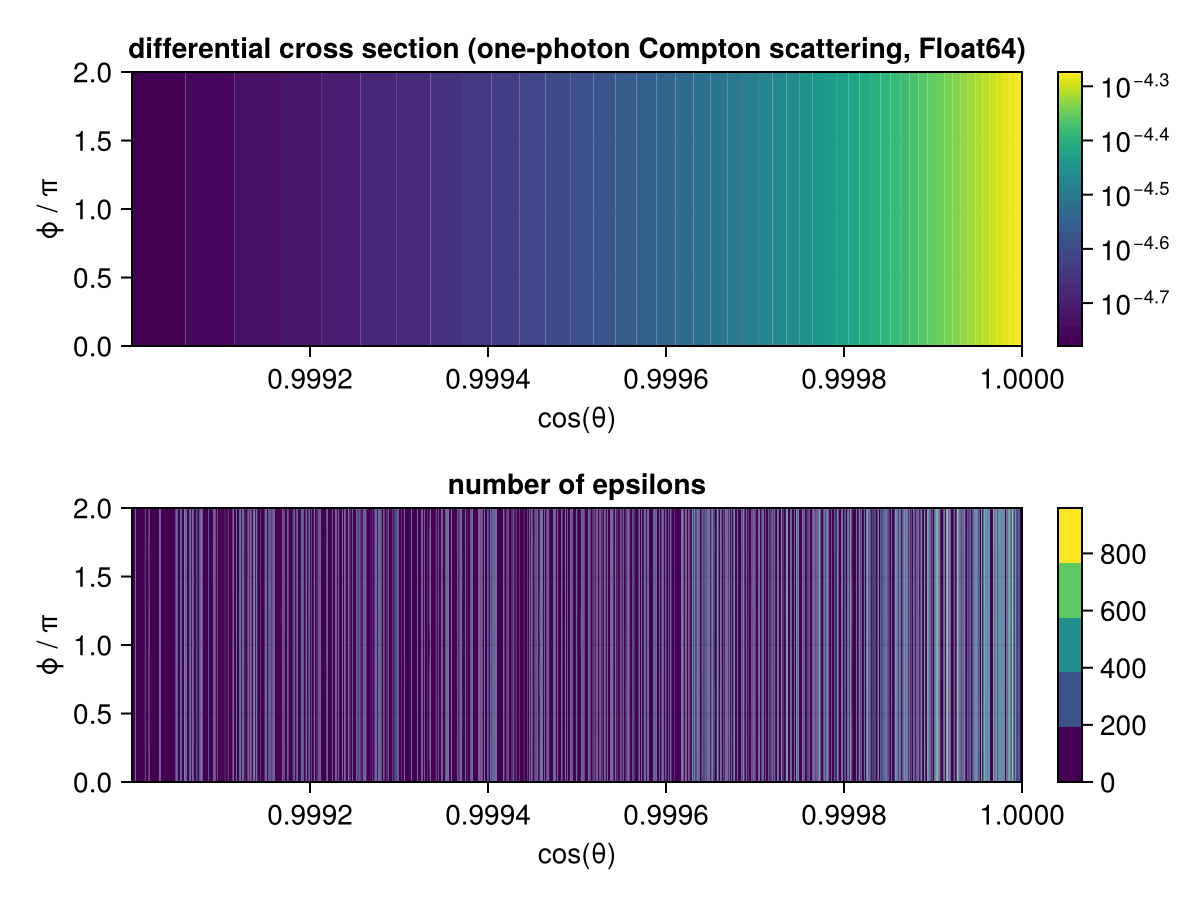

In [30]:
using CairoMakie

f = Figure(;)
ax1 = Axis(f[1, 1]; title = "differential cross section ($PROC, $(eltype(FLOAT_T)))", xlabel = "cos(θ)", ylabel = "ϕ / π")
ax2 = Axis(f[2, 1]; title = "number of epsilons", xlabel = "cos(θ)", ylabel = "ϕ / π")

vals = getfield.(out_matrix, :x)
co_vals = contourf!(ax1, COS_THETAS, PHIS ./ π, vals; levels=50, colorscale=log10)

sig_digits = PrecisionCarriers._no_epsilons.(out_matrix)
@show maximum(sig_digits)
co_sig_digits = contourf!(ax2, COS_THETAS, PHIS ./ π, sig_digits; levels=5)

Colorbar(f[1, 2], co_vals)
Colorbar(f[2, 2], co_sig_digits)

f

In [15]:
save("compton_epsilons_$(eltype(FLOAT_T))_$OMEGA.pdf", f)

CairoMakie.Screen{PDF}
